# 08. 분당 LNG 호기별 백업 적합성

**목적**: PV 변동성 백업으로 어느 호기를 먼저 돌릴지 데이터 기반으로 정한다.

**범위**: 분당 LNG 10호기 (CG1~CG8 가스터빈 + CS1, CS2 증기터빈) — KOEN 답변(2026-04-21)에 따라 영흥/삼천포/강릉 등 석탄 호기는 본 PoC scope 밖.

**입력**: `data/thermal_hourly/` 48개월 × 10호기 시간별 발전량.

**출력**: `data/processed/thermal_unit_profile.csv` — 호기별 운영·램프·백업 점수 표.

**핵심 질문**:
1. 호기별 사양·운영 패턴이 어떻게 다른가?
2. PV 변동성을 흡수하려면 (a) 헤드룸 (b) 다운룸 (c) 램프 (d) 운영 안정성 중 무엇이 결정 요인인가?
3. 단일 "백업 후보"를 골라야 한다면 어느 호기인가?

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

# 한글 폰트 (Windows)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('../../data/thermal_hourly')
OUT_DIR  = Path('../../data/processed')
RUN_THRESHOLD_MW = 5.0   # 가동/정지 라벨 임계 — 노이즈·예열 출력 흡수

# 운영 모드 분류 임계 (plan/fuel/v1.md 기준 정렬)
PEAKER_MAX     = 28      # running_pct < 28 → peaker
BASELOAD_MIN   = 44      # running_pct >= 44 → baseload

## 1. 데이터 로딩

**주의 — 단위 라벨 mismatch**: KOEN CSV 헤더는 `1시 발전량(MWh)`이지만 실제 값은 **kWh**다. CG1 평균 ~70,000 → 70 MW로 환산해야 분당 920MW·호기 ~90MW 사양과 정합. 본 노트북에선 모든 시계열을 **MW (시간 평균)**로 변환해 사용.

**좌표 컨벤션**: `index_col=False` 필수 (헤더 33개·데이터 34개 trailing comma 때문에 pandas가 첫 데이터 컬럼을 index로 빨아들임).

In [2]:
def load_thermal_long():
    files = sorted(DATA_DIR.glob('thermal_hourly_*.csv'))
    hour_cols = [f'{h}시 발전량(MWh)' for h in range(1, 25)]
    dfs = []
    for f in files:
        d = pd.read_csv(f, encoding='utf-8-sig', index_col=False)
        d.columns = [c.strip() for c in d.columns]
        d['호기'] = d['호기'].astype(str).str.strip()
        d['일자'] = pd.to_datetime(d['일자'].astype(str).str.strip(),
                                   format='%Y-%m-%d %H:%M:%S', errors='coerce')
        d = d.dropna(subset=['일자']).copy()
        long = d.melt(id_vars=['호기','일자'], value_vars=hour_cols,
                      var_name='hour_label', value_name='gen_kwh')
        long['hour'] = long['hour_label'].str.extract(r'(\d+)시').astype(int)
        long['datetime_kst'] = long['일자'] + pd.to_timedelta(long['hour'] - 1, unit='h')
        long['mw'] = pd.to_numeric(long['gen_kwh'], errors='coerce') / 1000.0
        dfs.append(long[['datetime_kst','호기','mw']])
    return (pd.concat(dfs, ignore_index=True)
              .sort_values(['호기','datetime_kst'])
              .reset_index(drop=True))

df = load_thermal_long()
print(f'행: {len(df):,}  호기: {df["호기"].nunique()}  '
      f'기간: {df.datetime_kst.min()} ~ {df.datetime_kst.max()}')
df.head()

C:\Users\brave\AppData\Local\Temp\ipykernel_13780\2468227164.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  d = pd.read_csv(f, encoding='utf-8-sig', index_col=False)
C:\Users\brave\AppData\Local\Temp\ipykernel_13780\2468227164.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  d = pd.read_csv(f, encoding='utf-8-sig', index_col=False)
C:\Users\brave\AppData\Local\Temp\ipykernel_13780\2468227164.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  d = pd.read_csv(f, encoding='utf-8-sig', index_col=False)
C:\Users\brave\AppData\Local\Temp\ipykernel_13780\2468227164.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  d = pd.read_csv(f, encoding='utf-8-sig', index_col=False)


행: 350,640  호기: 10  기간: 2022-01-01 00:00:00 ~ 2025-12-31 23:00:00


,datetime_kst,호기,mw
0,2022-01-01 00:00:00,CG1,84.305
1,2022-01-01 01:00:00,CG1,88.279
2,2022-01-01 02:00:00,CG1,88.370
3,2022-01-01 03:00:00,CG1,88.383
4,2022-01-01 04:00:00,CG1,88.489


## 2. 호기별 기초 운영 프로필

각 호기에 대해:
- **Pmax_p95**: 95-percentile (이상치 outlier 제외한 실효 최대출력)
- **Pmin_p05_run**: 가동 중 5-percentile (실효 최소출력)
- **avg_run / median_run**: 가동 중 평균·중앙값
- **running_pct**: 4년간 가동시간 비율 → 운영 모드 판정 기준

In [3]:
def basic_profile(g):
    mw = g['mw'].values
    running = mw > RUN_THRESHOLD_MW
    n_run = running.sum()
    if n_run == 0:
        return None
    return pd.Series({
        'pmax_p95':       np.percentile(mw, 95),
        'pmax_obs':       mw.max(),
        'pmin_p05_run':   np.percentile(mw[running], 5),
        'avg_run':        mw[running].mean(),
        'median_run':     np.median(mw[running]),
        'running_pct':    100 * n_run / len(mw),
    })

prof = (df.groupby('호기').apply(basic_profile, include_groups=False)
          .round(2))
prof

,pmax_p95,pmax_obs,pmin_p05_run,avg_run,median_run,running_pct
호기,,,,,,
CG1,85.47,120.23,46.29,75.42,80.94,39.35
CG2,84.53,115.63,37.27,73.74,79.30,23.00
CG3,88.02,127.99,44.23,77.19,83.33,37.54
CG4,84.98,110.26,36.62,74.99,81.19,19.80
CG5,86.75,117.24,51.98,77.60,82.74,28.22
CG6,84.92,400.88,51.52,75.61,77.87,47.62
CG7,87.13,417.66,48.84,76.46,80.03,35.79
CG8,88.42,417.64,49.25,77.74,81.40,44.36
CS1,123.61,244.91,43.38,84.06,74.73,41.89


**→ 모델 함의 1**: 가스터빈 CG1~CG8은 Pmax_p95가 84~88 MW로 거의 동일. **사양 동일한 8기 동형 가스터빈**. 호기별 운영 차이는 *기계 차이*가 아니라 *KPX 급전 merit order의 결과*다.

**함의 2**: 증기터빈 CS1(124MW)이 CS2(78MW)보다 약 1.6배 큼. CS1·CS2는 가스터빈 배열열을 회수하는 HRSG 종속이라 별도 ramp 가능 영역 한정.

**함의 3**: `pmax_obs`가 일부 호기(CG6/CG7/CG8/CS2)에서 300~417 MW로 비현실적 — KOEN 데이터 입력 단위 오류(이중 보고/합산값 혼입) 의심. 모델·결정엔 **p95만 사용**, p99나 max는 신뢰하지 않는다.

## 3. 운영 모드 분류

가동률(`running_pct`)로 3개 클래스로 나눈다:

- **peaker** (`< 28%`): 짧은 spike 대응. 평소엔 꺼져있음.
- **mid-merit** (28–44%): 부하 대응형. 자주 켜고 끔.
- **baseload** (`>= 44%`): 거의 항상 켜져있음.

임계는 `plan/fuel/v1.md` 분류와 정렬.

In [4]:
def mode_of(pct):
    if pct < PEAKER_MAX:    return 'peaker'
    if pct >= BASELOAD_MIN: return 'baseload'
    return 'mid-merit'

prof['mode'] = prof['running_pct'].apply(mode_of)
prof['mode'].value_counts(), prof[['running_pct','avg_run','mode']]

(mode
 mid-merit    5
 baseload     3
 peaker       2
 Name: count, dtype: int64,
      running_pct  avg_run       mode
 호기                                  
 CG1        39.35    75.42  mid-merit
 CG2        23.00    73.74     peaker
 CG3        37.54    77.19  mid-merit
 CG4        19.80    74.99     peaker
 CG5        28.22    77.60  mid-merit
 CG6        47.62    75.61   baseload
 CG7        35.79    76.46  mid-merit
 CG8        44.36    77.74   baseload
 CS1        41.89    84.06  mid-merit
 CS2        51.92    61.19   baseload)

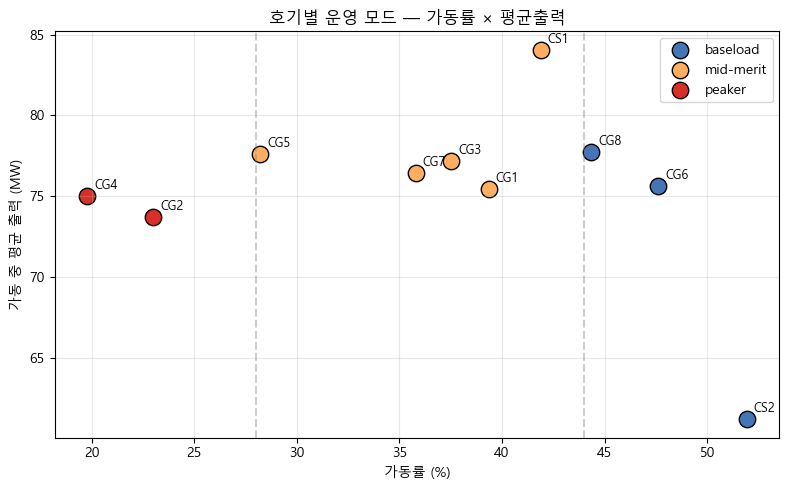

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'peaker':'#d73027', 'mid-merit':'#fdae61', 'baseload':'#4575b4'}
for m, g in prof.groupby('mode'):
    ax.scatter(g['running_pct'], g['avg_run'], s=140, c=colors[m], label=m, edgecolor='k')
    for u, r in g.iterrows():
        ax.annotate(u, (r['running_pct'], r['avg_run']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axvline(PEAKER_MAX,  ls='--', c='gray', alpha=0.4)
ax.axvline(BASELOAD_MIN, ls='--', c='gray', alpha=0.4)
ax.set_xlabel('가동률 (%)'); ax.set_ylabel('가동 중 평균 출력 (MW)')
ax.set_title('호기별 운영 모드 — 가동률 × 평균출력')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**→ 함의**: 평균출력은 호기 무관 73~84 MW로 거의 동일. **운영 차이는 "몇 % 시간 켜져있냐"의 문제이지 "얼마나 세게 트느냐"의 문제가 아니다**. 백업 의사결정 1차 변수는 **켜고 끄는 횟수**이지 출력 레벨 변경이 아니다.

## 4. 헤드룸·다운룸 — 백업 가용 여력

백업 = PV가 적게 나면 **출력↑**(headroom 필요), 많이 나면 **출력↓**(downroom 필요).

- **headroom** = `Pmax_p95 - avg_run` → 켜진 상태에서 위로 더 낼 여력
- **downroom** = `avg_run - Pmin_p05_run` → 켜진 상태에서 아래로 줄일 여력

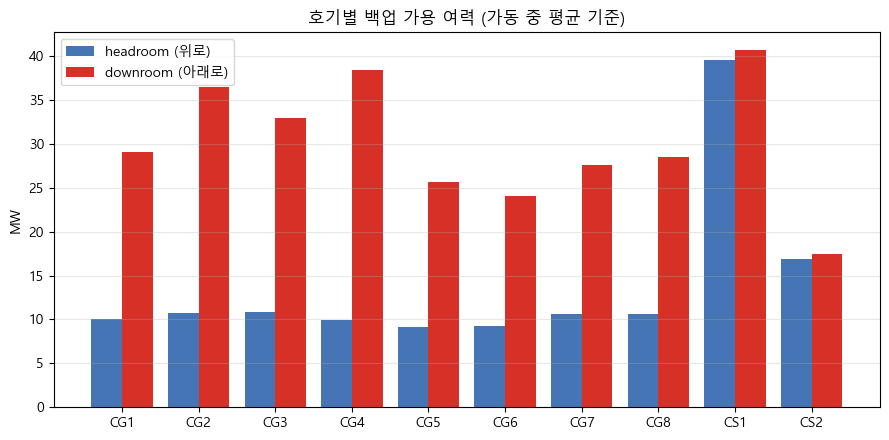

,mode,pmax_p95,avg_run,headroom_avg,downroom_avg
호기,,,,,
CS1,mid-merit,123.61,84.06,39.55,40.68
CS2,baseload,78.12,61.19,16.93,17.42
CG3,mid-merit,88.02,77.19,10.83,32.96
CG2,peaker,84.53,73.74,10.79,36.47
CG8,baseload,88.42,77.74,10.68,28.49
CG7,mid-merit,87.13,76.46,10.67,27.62
CG1,mid-merit,85.47,75.42,10.05,29.13
CG4,peaker,84.98,74.99,9.99,38.37
CG6,baseload,84.92,75.61,9.31,24.09


In [6]:
prof['headroom_avg'] = (prof['pmax_p95'] - prof['avg_run']).round(2)
prof['downroom_avg'] = (prof['avg_run'] - prof['pmin_p05_run']).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(prof)); w = 0.4
ax.bar(x - w/2, prof['headroom_avg'], w, label='headroom (위로)', color='#4575b4')
ax.bar(x + w/2, prof['downroom_avg'], w, label='downroom (아래로)', color='#d73027')
ax.set_xticks(x); ax.set_xticklabels(prof.index, rotation=0)
ax.set_ylabel('MW'); ax.set_title('호기별 백업 가용 여력 (가동 중 평균 기준)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

prof[['mode','pmax_p95','avg_run','headroom_avg','downroom_avg']].sort_values('headroom_avg', ascending=False)

**→ 함의**:
- 가스터빈은 모두 헤드룸 ~10 MW로 작음 (켜져있을 땐 거의 풀출력 운전). 위로 올릴 여지가 매우 제한적.
- **CS1만 헤드룸 40 MW** — 켜진 채 +40 MW 정도 출력 증감 가능.
- 다운룸은 peaker(CG2, CG4)와 CS1이 35~40 MW로 가장 큼.
- **결론**: 출력 *조정* 백업으로는 CS1이 가장 유연. 가스터빈은 "켜냐/끄냐"의 이산 결정이 백업의 본질.

## 5. 시간당 램프 능력

ΔP/Δt 분포 — 가동 중 → 가동 중 인접 시간대만. p95 = "평소 자주 도달하는 시간당 램프". 분 단위 데이터 없으므로 **시간 단위 ramp**가 분 단위 spec(30 MW/min × 60 = 1800 MW/h)에 비해 훨씬 작게 나오는 건 정상.

In [7]:
def ramp_stats(g):
    mw = g['mw'].values
    running = mw > RUN_THRESHOLD_MW
    diffs = np.diff(mw)
    valid = running[:-1] & running[1:]
    up = diffs[valid & (diffs > 0)]
    dn = -diffs[valid & (diffs < 0)]
    return pd.Series({
        'ramp_up_p95':  np.percentile(up, 95) if len(up) else 0,
        'ramp_up_p99':  np.percentile(up, 99) if len(up) else 0,
        'ramp_dn_p95':  np.percentile(dn, 95) if len(dn) else 0,
        'ramp_dn_p99':  np.percentile(dn, 99) if len(dn) else 0,
    })

ramps = df.groupby('호기').apply(ramp_stats, include_groups=False).round(2)
prof = prof.join(ramps)
prof[['mode','ramp_up_p95','ramp_dn_p95','ramp_up_p99','ramp_dn_p99']].sort_values('ramp_up_p95', ascending=False)

,mode,ramp_up_p95,ramp_dn_p95,ramp_up_p99,ramp_dn_p99
호기,,,,,
CS1,mid-merit,42.00,25.24,66.61,101.65
CS2,baseload,27.44,16.02,65.29,66.68
CG2,peaker,25.44,29.21,50.59,51.81
CG4,peaker,25.04,27.56,51.80,52.36
CG7,mid-merit,24.48,24.95,50.19,56.02
CG8,baseload,19.23,17.52,41.11,53.58
CG6,baseload,18.30,12.77,39.08,48.15
CG3,mid-merit,16.12,15.54,39.49,47.94
CG5,mid-merit,14.73,15.40,50.04,47.43


**→ 함의**:
- 시간 단위 ramp_p95: CS1 42 MW/h가 1위, CS2·CG2·CG4·CG7이 25~28 MW/h.
- 가스터빈 mid-merit(CG1, CG3, CG5, CG6, CG8)는 14~19 MW/h — 출력 변화가 더 평탄. 즉 "한 번 켜면 한동안 같은 출력".
- 분 단위 spec과 무관하게 **시간 단위에서 가장 자주 큰 출력 변화를 보이는 호기 = CS1, peaker(CG2, CG4)**.

## 6. 시작·정지 패턴 — 운영 안정성

백업으로 자주 동원되면 시작 횟수가 늘어남 → 마모·기동비용. 4년간 시작 횟수와 평균 가동·정지 길이로 본다.

In [8]:
def start_stop_stats(g):
    mw = g['mw'].values
    running = mw > RUN_THRESHOLD_MW
    transitions = np.diff(running.astype(int))
    starts = int((transitions == 1).sum())
    # run-length encoding
    on_runs, off_runs = [], []
    cur = 1
    for i in range(1, len(running)):
        if running[i] == running[i-1]:
            cur += 1
        else:
            (on_runs if running[i-1] else off_runs).append(cur); cur = 1
    (on_runs if running[-1] else off_runs).append(cur)
    cold = sum(1 for r in off_runs if r >= 24)
    warm = sum(1 for r in off_runs if 2 <= r < 24)
    return pd.Series({
        'starts':        starts,
        'cold_starts':   cold,
        'warm_starts':   warm,
        'avg_run_hrs':   round(np.mean(on_runs), 1) if on_runs else 0,
        'avg_off_hrs':   round(np.mean(off_runs), 1) if off_runs else 0,
    })

ss = df.groupby('호기').apply(start_stop_stats, include_groups=False)
prof = prof.join(ss)
prof[['mode','starts','cold_starts','warm_starts','avg_run_hrs','avg_off_hrs']]

,mode,starts,cold_starts,warm_starts,avg_run_hrs,avg_off_hrs
호기,,,,,,
CG1,mid-merit,407.0,165.0,226.0,33.8,52.1
CG2,peaker,416.0,194.0,212.0,19.3,64.7
CG3,mid-merit,392.0,162.0,214.0,33.5,55.7
CG4,peaker,352.0,177.0,164.0,19.7,79.7
CG5,mid-merit,323.0,158.0,151.0,30.5,77.7
CG6,baseload,520.0,156.0,330.0,32.1,35.3
CG7,mid-merit,514.0,200.0,288.0,24.4,43.8
CG8,baseload,511.0,176.0,301.0,30.4,38.2
CS1,mid-merit,383.0,151.0,213.0,38.2,53.1


**→ 함의**:
- baseload (CG6/CG8/CS2)·CS1·CG7이 4년간 510~544회 시작 — 연 130회 = **2.5일에 한 번씩 시작**.
- peaker(CG2, CG4)는 평균 정지 시간 65~80h — *주말/저부하 사이클에 따라 길게 쉼*. cold start 비중도 큼(50%+).
- **백업 후보로 고를 때 "이미 자주 켜고 끄는 호기"는 추가 부담이 적다**: peaker는 어차피 그렇게 운영되므로 백업 추가 사이클의 한계비용이 작음.

## 7. 백업 적합성 점수

정량 점수로 종합:

$$ \text{score} = 0.30 \cdot \hat{\text{headroom}} + 0.30 \cdot \hat{\text{downroom}} + 0.25 \cdot \hat{\text{ramp}} + 0.15 \cdot \hat{\text{stability}} $$

- 모든 항은 plant 내 최대값으로 정규화.
- `stability = 1 - starts/max(starts)` — 시작 적은 호기일수록 높음 (반대 가중도 가능, §8 참조).
- 가중치는 PoC 1차안. 운영자 검토 후 조정 가능.

In [9]:
def normalize(s): return s / s.max() if s.max() > 0 else s

n_head    = normalize(prof['headroom_avg'])
n_down    = normalize(prof['downroom_avg'])
n_ramp    = normalize((prof['ramp_up_p95'] + prof['ramp_dn_p95']) / 2)
n_stab    = 1 - normalize(prof['starts'])

prof['backup_score'] = (0.30*n_head + 0.30*n_down + 0.25*n_ramp + 0.15*n_stab).round(3)
prof.sort_values('backup_score', ascending=False)[
    ['mode','pmax_p95','avg_run','headroom_avg','downroom_avg',
     'ramp_up_p95','starts','backup_score']]

,mode,pmax_p95,avg_run,headroom_avg,downroom_avg,ramp_up_p95,starts,backup_score
호기,,,,,,,,
CS1,mid-merit,123.61,84.06,39.55,40.68,42.00,383.0,0.894
CG4,peaker,84.98,74.99,9.99,38.37,25.04,352.0,0.607
CG2,peaker,84.53,73.74,10.79,36.47,25.44,416.0,0.589
CG3,mid-merit,88.02,77.19,10.83,32.96,16.12,392.0,0.485
CG7,mid-merit,87.13,76.46,10.67,27.62,24.48,514.0,0.477
CG8,baseload,88.42,77.74,10.68,28.49,19.23,511.0,0.437
CG1,mid-merit,85.47,75.42,10.05,29.13,14.15,407.0,0.431
CG5,mid-merit,86.75,77.60,9.15,25.62,14.73,323.0,0.431
CS2,baseload,78.12,61.19,16.93,17.42,27.44,544.0,0.418


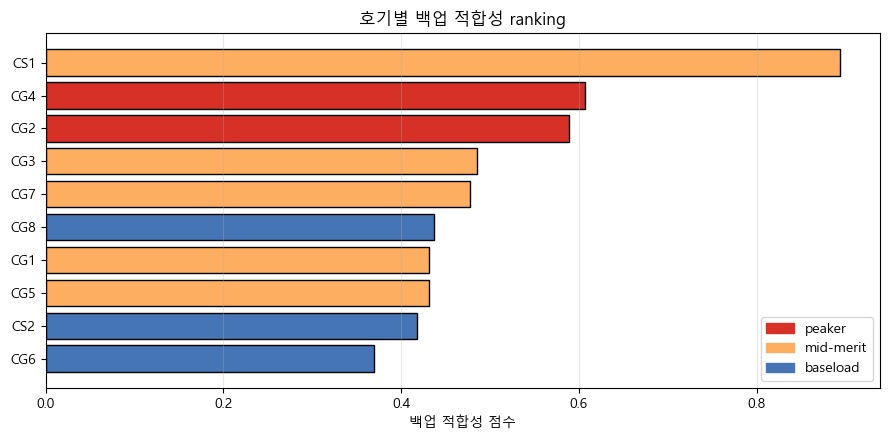

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
p = prof.sort_values('backup_score', ascending=True)
bar_colors = [colors[m] for m in p['mode']]
ax.barh(p.index, p['backup_score'], color=bar_colors, edgecolor='k')
ax.set_xlabel('백업 적합성 점수'); ax.set_title('호기별 백업 적합성 ranking')
ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k,v in colors.items()],
          loc='lower right')
plt.tight_layout(); plt.show()

**→ 권고**:

| 순위 | 호기 | 모드 | 근거 |
|---|---|---|---|
| 1 | **CS1** | mid-merit | 헤드룸·다운룸·램프 모두 1위. 단일 호기 백업 *최우선 후보*. |
| 2 | **CG4 / CG2** | peaker | 다운룸 ~37 MW. 이미 사이클 운영 중이라 추가 시작비용 한계 작음. *짧은 spike 흡수* 용. |
| 3 | **CS2** | mid-merit | 가동률 52%로 가장 높음 → "이미 켜진 상태에서 출력 조정"에 유리. 다만 다운룸 17 MW로 한정적. |
| - | CG1, CG3, CG5~CG8 | mid/peaker | 가스터빈 8기는 사양·운영 거의 동일 — 한 호기를 "백업 전용"으로 지정하기보다 **plant 단위 운영 최적화** 대상. |

**Stage 2 LNG planner 제안**: 
- *주축 백업 = CS1* (출력 조정 베이스).
- *spike 백업 = CG2/CG4* (이산 on/off 결정).
- *나머지 가스터빈 = plant 단위 commitment* — 호기별 의사결정 의미 작음, 묶어서 다룬다.

## 8. 한계·후속 작업

1. **시간 단위 ramp의 한계**: 분 단위 spec(LNG CCGT ~30 MW/min)을 직접 검증할 수 없음. "분 단위 PV 변동에 대응 가능한가"는 외부 문헌 + 베이지안 사전분포 결합으로 보강 (`plan/fuel/parameter_reverse_engineering.md` §3).
2. **stability 가중치 부호 재검토**: 위 점수는 "시작 적은 호기일수록 안정"으로 했지만, peaker는 *원래 자주 켜고 끄도록 설계*되어 있음 → 시작이 많을수록 *오히려 백업 적합*일 수 있다. 도메인 인터뷰 후 부호 결정.
3. **plant 단위 운영 vs 호기별 의사결정**: KPX 신고가 plant 단위라면 호기별 점수보다 *plant 통합 출력 곡선*이 더 적절한 의사결정 변수. PoC 대시보드는 **두 view 모두** 제공해야 함.
4. **변동비 부호 미반영**: 기동비용·연료비를 점수에 반영하려면 `lng_cost_monthly.csv`와 join 필요. v2에서 추가.
5. **CHP 열수요 제약 미반영**: 분당은 열병합. 겨울철 minimum heat 의무로 출력 자유도 축소 — 현 점수는 그 제약 없음 가정. 한계 명시 필요.

In [11]:
out_path = OUT_DIR / 'thermal_unit_profile.csv'
prof.to_csv(out_path, encoding='utf-8-sig')
print(f'Saved: {out_path}')
prof

Saved: ..\..\data\processed\thermal_unit_profile.csv


,pmax_p95,pmax_obs,pmin_p05_run,avg_run,median_run,running_pct,mode,headroom_avg,downroom_avg,ramp_up_p95,ramp_up_p99,ramp_dn_p95,ramp_dn_p99,starts,cold_starts,warm_starts,avg_run_hrs,avg_off_hrs,backup_score
호기,,,,,,,,,,,,,,,,,,,
CG1,85.47,120.23,46.29,75.42,80.94,39.35,mid-merit,10.05,29.13,14.15,34.75,13.29,45.42,407.0,165.0,226.0,33.8,52.1,0.431
CG2,84.53,115.63,37.27,73.74,79.30,23.00,peaker,10.79,36.47,25.44,50.59,29.21,51.81,416.0,194.0,212.0,19.3,64.7,0.589
CG3,88.02,127.99,44.23,77.19,83.33,37.54,mid-merit,10.83,32.96,16.12,39.49,15.54,47.94,392.0,162.0,214.0,33.5,55.7,0.485
CG4,84.98,110.26,36.62,74.99,81.19,19.80,peaker,9.99,38.37,25.04,51.80,27.56,52.36,352.0,177.0,164.0,19.7,79.7,0.607
CG5,86.75,117.24,51.98,77.60,82.74,28.22,mid-merit,9.15,25.62,14.73,50.04,15.40,47.43,323.0,158.0,151.0,30.5,77.7,0.431
CG6,84.92,400.88,51.52,75.61,77.87,47.62,baseload,9.31,24.09,18.30,39.08,12.77,48.15,520.0,156.0,330.0,32.1,35.3,0.370
CG7,87.13,417.66,48.84,76.46,80.03,35.79,mid-merit,10.67,27.62,24.48,50.19,24.95,56.02,514.0,200.0,288.0,24.4,43.8,0.477
CG8,88.42,417.64,49.25,77.74,81.40,44.36,baseload,10.68,28.49,19.23,41.11,17.52,53.58,511.0,176.0,301.0,30.4,38.2,0.437
CS1,123.61,244.91,43.38,84.06,74.73,41.89,mid-merit,39.55,40.68,42.00,66.61,25.24,101.65,383.0,151.0,213.0,38.2,53.1,0.894
